In [45]:
!pip install seaborn
!pip install scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
  Using cached scikit_learn-1.9.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 26.2 MB/s eta 0:00:00 MB/s eta 0:00:01:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style("white")
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")
print("Path to dataset files:", path)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8.17M/8.17M [00:01<00:00, 6.74MB/s]

Extracting files...
Path to dataset files: /home/ben/.cache/kagglehub/datasets/maharshipandya/-spotify-tracks-dataset/versions/1


In [6]:
file_path = '/home/ben/.cache/kagglehub/datasets/maharshipandya/-spotify-tracks-dataset/versions/1/dataset.csv'
df = pd.read_csv(file_path)

In [7]:
pd.set_option('display.float_format', '{:.3f}'.format)
print(df.describe())

       Unnamed: 0  popularity  duration_ms  danceability     energy  \
count  114000.000  114000.000   114000.000    114000.000 114000.000   
mean    56999.500      33.239   228029.153         0.567      0.641   
std     32909.110      22.305   107297.713         0.174      0.252   
min         0.000       0.000        0.000         0.000      0.000   
25%     28499.750      17.000   174066.000         0.456      0.472   
50%     56999.500      35.000   212906.000         0.580      0.685   
75%     85499.250      50.000   261506.000         0.695      0.854   
max    113999.000     100.000  5237295.000         0.985      1.000   

             key   loudness       mode  speechiness  acousticness  \
count 114000.000 114000.000 114000.000   114000.000    114000.000   
mean       5.309     -8.259      0.638        0.085         0.315   
std        3.560      5.029      0.481        0.106         0.333   
min        0.000    -49.531      0.000        0.000         0.000   
25%        2.00

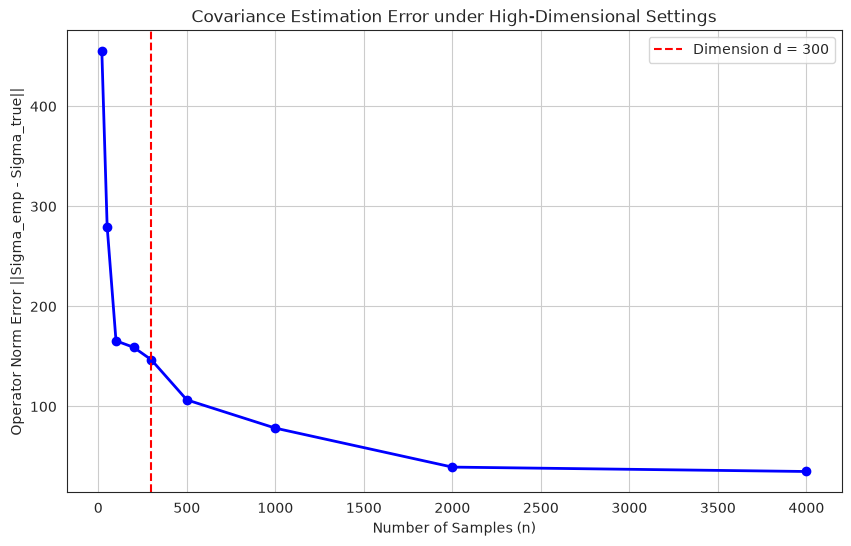

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Select continuous features from the pre-loaded dataframe
features = ['danceability', 'energy', 'loudness', 'speechiness', 
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'popularity']

df_clean = df[features].dropna()

# 2. Compute the baseline covariance matrix (10x10)
Sigma_base = df_clean.cov().to_numpy()

# 3. Inflate the dimension to d = 300 (high-dimensional phenomenon)
d = 300
Sigma_high = np.zeros((d, d))
Sigma_high[0:10, 0:10] = Sigma_base

# Add controlled noise to ensure the matrix is symmetric and positive definite
A = np.random.randn(d, d) * 0.1
Sigma_high = Sigma_high + np.dot(A, A.T)
np.fill_diagonal(Sigma_high, np.diagonal(Sigma_high) + 0.5)

# 4. Concentration bounds experiment - evaluate error as a function of sample size (n)
n_samples_range = [20, 50, 100, 200, 300, 500, 1000, 2000, 4000]
errors = []
mean = np.zeros(d)

for n in n_samples_range:
    # Sample n synthetic songs from the high-dimensional distribution
    X = np.random.multivariate_normal(mean, Sigma_high, size=n)
    
    # Compute the empirical covariance matrix from the sample
    Sigma_empirical = np.cov(X, rowvar=False)
    
    # Compute the estimation error using the operator norm (spectral norm)
    error = np.linalg.norm(Sigma_empirical - Sigma_high, ord=2)
    errors.append(error)

# 5. Plotting the graph
plt.figure(figsize=(10, 6))
plt.plot(n_samples_range, errors, marker='o', color='b', linewidth=2)
plt.axvline(x=d, color='r', linestyle='--', label=f'Dimension d = {d}')
plt.xlabel('Number of Samples (n)')
plt.ylabel('Operator Norm Error ||Sigma_emp - Sigma_true||')
plt.title('Covariance Estimation Error under High-Dimensional Settings')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
df = df.drop(columns=['Unnamed: 0'])
df
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  str    
 1   artists           113999 non-null  str    
 2   album_name        113999 non-null  str    
 3   track_name        113999 non-null  str    
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 non-nu

The top 10 artists are all renowned, with "The Beatles" being the most popular.

In [11]:
df=df.dropna()

In [12]:
df.isna().sum()

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [7]:
df=df.drop_duplicates()

In [13]:
df.shape

(113999, 20)

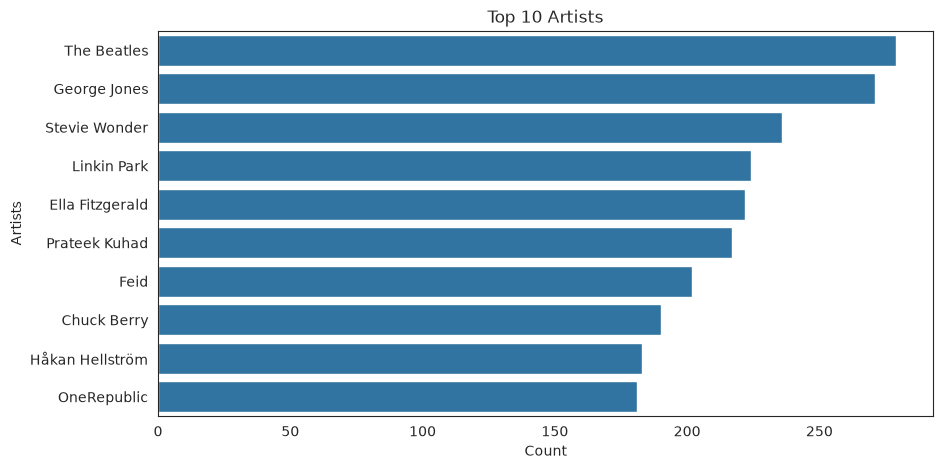

artists
The Beatles        279
George Jones       271
Stevie Wonder      236
Linkin Park        224
Ella Fitzgerald    222
Prateek Kuhad      217
Feid               202
Chuck Berry        190
Håkan Hellström    183
OneRepublic        181
Name: count, dtype: int64

In [14]:
plt.figure(figsize=(10, 5))
top_artists = df['artists'].value_counts().nlargest(10)
sns.barplot(y=top_artists.index, x=top_artists.values)
plt.title("Top 10 Artists")
plt.xlabel("Count")
plt.ylabel("Artists")
plt.show()
top_artists

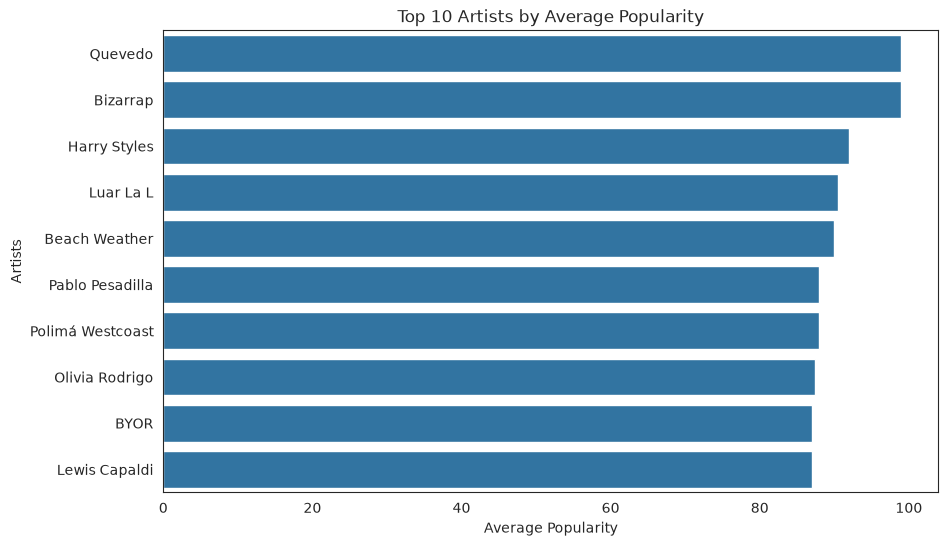

artists
Quevedo            99.000
Bizarrap           99.000
Harry Styles       92.000
Luar La L          90.500
Beach Weather      90.000
Pablo Pesadilla    88.000
Polimá Westcoast   88.000
Olivia Rodrigo     87.400
BYOR               87.000
Lewis Capaldi      87.000
Name: popularity, dtype: float64


In [15]:
copy_df = df.copy()
copy_df['artists'] = copy_df['artists'].str.split(';')
copy_df = copy_df.explode('artists')

top_artists = copy_df.groupby('artists')['popularity'].mean()
top_artists = top_artists[top_artists >= 70].sort_values(ascending=False)
top_artists_top10 = top_artists[:10]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_artists_top10.values, y=top_artists_top10.index)
plt.title('Top 10 Artists by Average Popularity')
plt.xlabel('Average Popularity')
plt.ylabel('Artists')
plt.show()

print(top_artists_top10)


 The top album and top track name are Halloween-themed and Christmas-themed

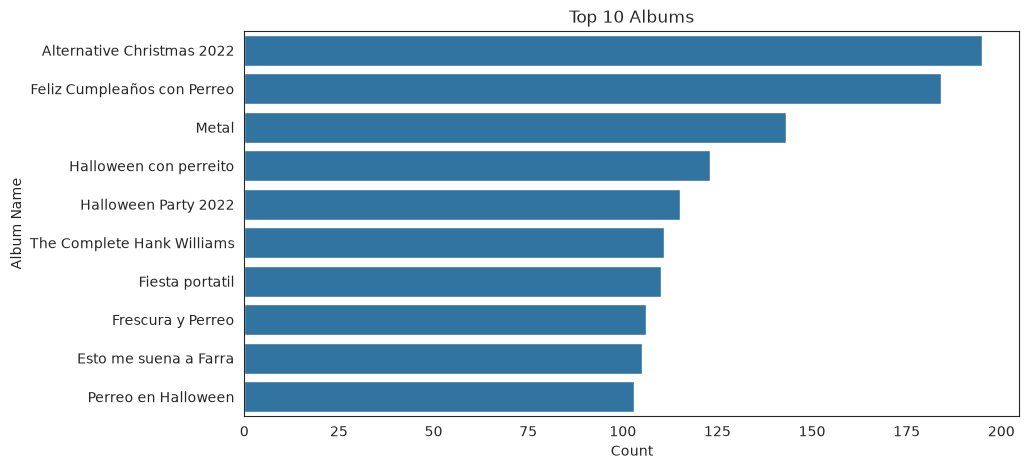

album_name
Alternative Christmas 2022     195
Feliz Cumpleaños con Perreo    184
Metal                          143
Halloween con perreito         123
Halloween Party 2022           115
The Complete Hank Williams     111
Fiesta portatil                110
Frescura y Perreo              106
Esto me suena a Farra          105
Perreo en Halloween            103
Name: count, dtype: int64

In [16]:
plt.figure(figsize=(10, 5))
top_albums = df['album_name'].value_counts().nlargest(10)
sns.barplot(y=top_albums.index, x=top_albums.values)
plt.title("Top 10 Albums")
plt.xlabel("Count")
plt.ylabel("Album Name")
plt.show()
top_albums

The top 10 track genres are all popular genres, and they all appear with the same frequency

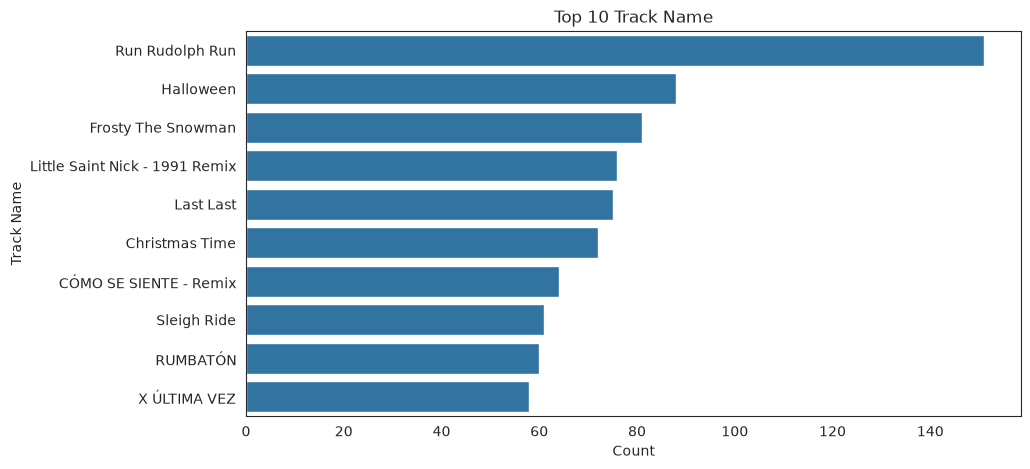

track_name
Run Rudolph Run                   151
Halloween                          88
Frosty The Snowman                 81
Little Saint Nick - 1991 Remix     76
Last Last                          75
Christmas Time                     72
CÓMO SE SIENTE - Remix             64
Sleigh Ride                        61
RUMBATÓN                           60
X ÚLTIMA VEZ                       58
Name: count, dtype: int64

In [17]:
plt.figure(figsize=(10, 5))
top_artists = df['track_name'].value_counts().nlargest(10)
sns.barplot(y=top_artists.index, x=top_artists.values)
plt.title("Top 10 Track Name")
plt.xlabel("Count")
plt.ylabel("Track Name")
plt.show()
top_artists

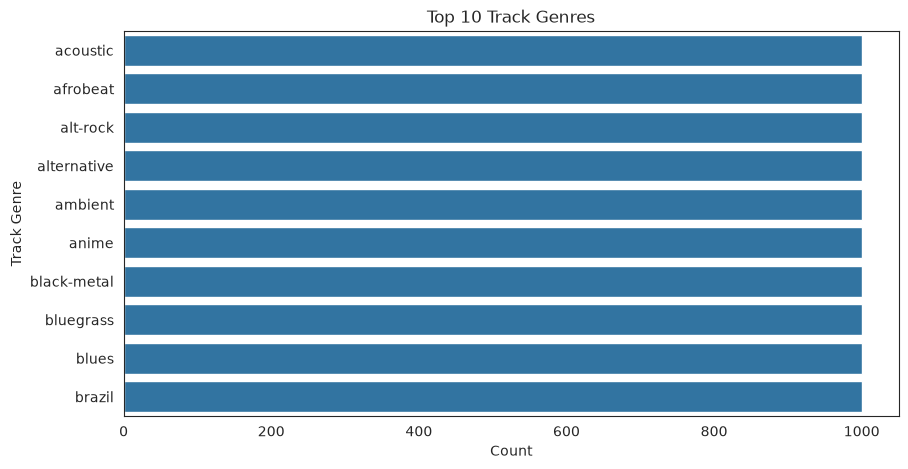

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
anime          1000
black-metal    1000
bluegrass      1000
blues          1000
brazil         1000
Name: count, dtype: int64

In [31]:
plt.figure(figsize=(10, 5))
top_genres = df['track_genre'].value_counts().nlargest(10)
sns.barplot(y=top_genres.index, x=top_genres.values)
plt.title("Top 10 Track Genres")
plt.xlabel("Count")
plt.ylabel("Track Genre")
plt.show()
top_genres

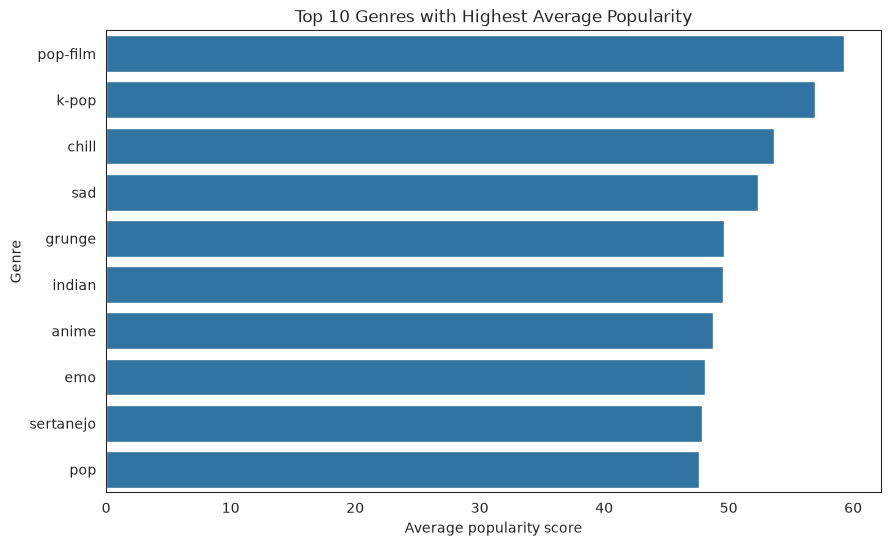

,track_genre,popularity
81,pop-film,59.283
65,k-pop,56.953
15,chill,53.651
94,sad,52.379
44,grunge,49.594
55,indian,49.539
5,anime,48.772
33,emo,48.128
97,sertanejo,47.866
80,pop,47.576


In [32]:
avg_popularity_by_genre = df.groupby('track_genre')['popularity'].mean().reset_index()
top10_popular_genres = avg_popularity_by_genre.nlargest(10, 'popularity')

plt.figure(figsize=(10, 6))
sns.barplot(x='popularity', y='track_genre', data=top10_popular_genres)
plt.title('Top 10 Genres with Highest Average Popularity')
plt.xlabel('Average popularity score')
plt.ylabel('Genre')
plt.show()

top10_popular_genres

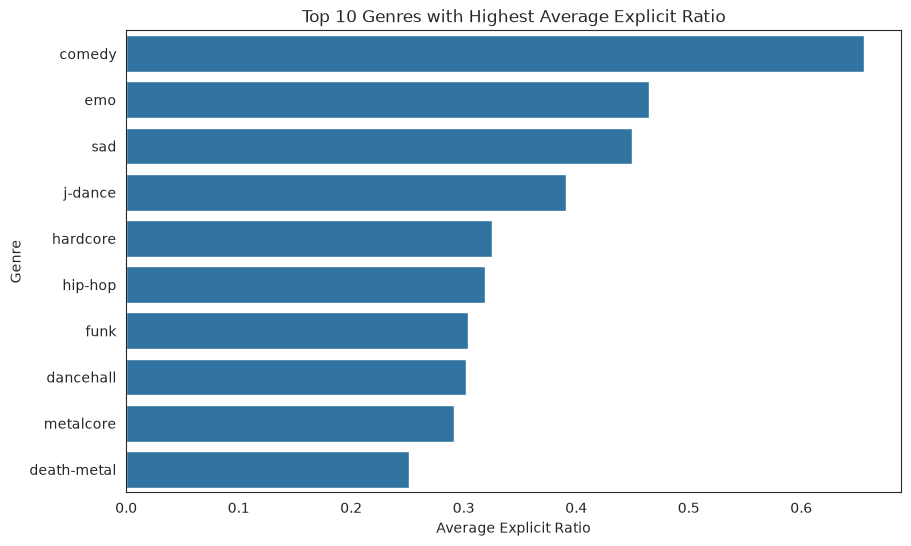

In [33]:
explicit_ratio_by_genre = df.groupby('track_genre')['explicit'].mean().reset_index()
top5_explicit_genres = explicit_ratio_by_genre.nlargest(10, 'explicit')

plt.figure(figsize=(10, 6))
sns.barplot(x='explicit', y='track_genre', data=top5_explicit_genres)
plt.title('Top 10 Genres with Highest Average Explicit Ratio')
plt.xlabel('Average Explicit Ratio')
plt.ylabel('Genre')
plt.show()

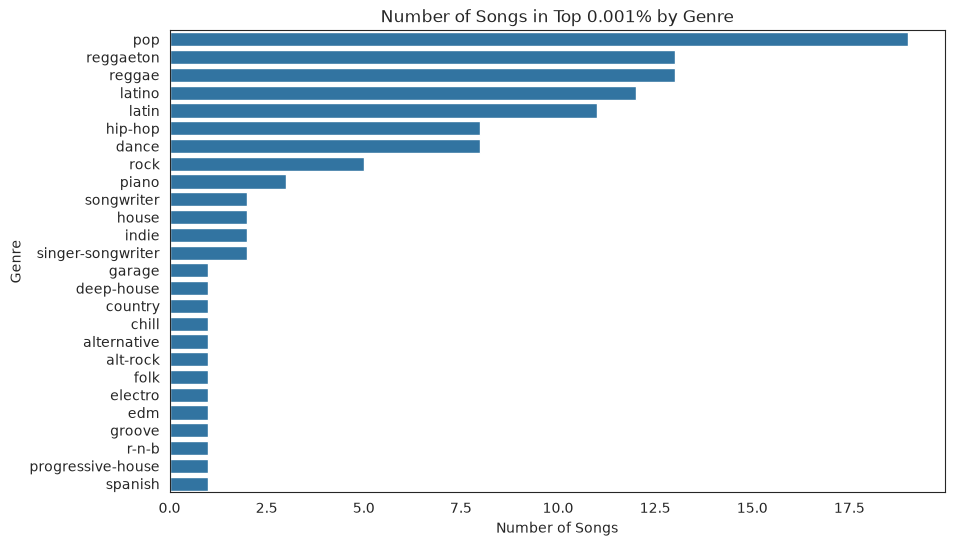

In [34]:
df_sorted = df.sort_values(by='popularity', ascending=False)
top_10_percent = df_sorted.head(int(0.001 * len(df_sorted)))
top_genres_count = top_10_percent.groupby('track_genre').size().reset_index(name='count')
top_genres_count = top_genres_count.sort_values(by='count', ascending=False)
most_common_genre = top_genres_count.loc[top_genres_count['count'].idxmax()]

plt.figure(figsize=(10, 6))
sns.barplot(x='count', y='track_genre', data=top_genres_count)
plt.title('Number of Songs in Top 0.001% by Genre')
plt.xlabel('Number of Songs')
plt.ylabel('Genre')
plt.show()

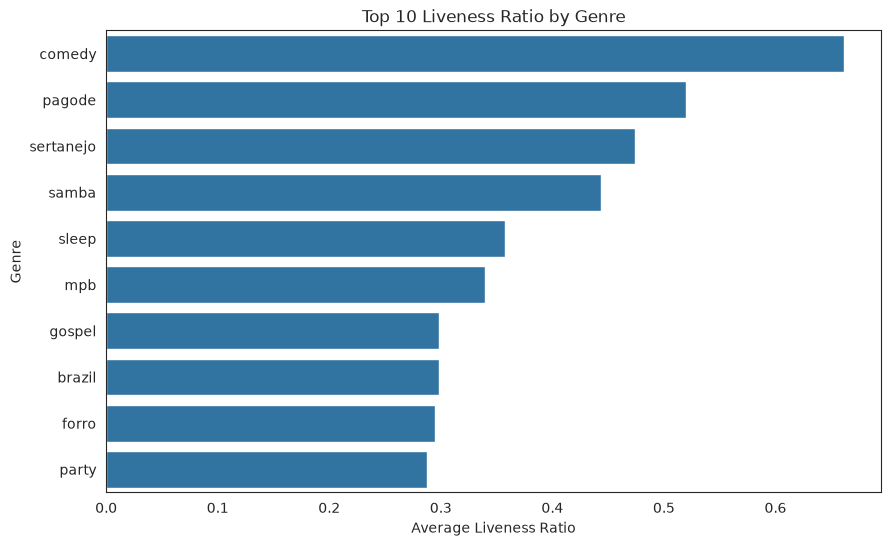

The genre with the highest liveness ratio is comedy with an average liveness ratio of 66.17%.


In [35]:
live_ratio_by_genre = df.groupby('track_genre')['liveness'].mean().reset_index()

top10_live_genres = live_ratio_by_genre.nlargest(10, 'liveness')
most_live_genre = live_ratio_by_genre.loc[live_ratio_by_genre['liveness'].idxmax()]

plt.figure(figsize=(10, 6))
sns.barplot(x='liveness', y='track_genre', data=top10_live_genres)
plt.title('Top 10 Liveness Ratio by Genre')
plt.xlabel('Average Liveness Ratio')
plt.ylabel('Genre')
plt.show()
print(f"The genre with the highest liveness ratio is {most_live_genre['track_genre']} with an average liveness ratio of {most_live_genre['liveness']:.2%}.")

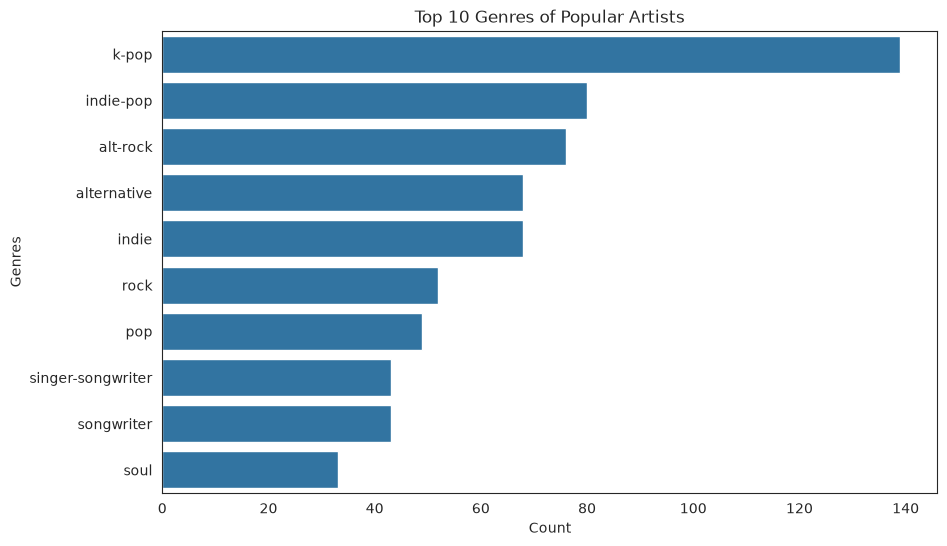

In [36]:
top_artists = copy_df.groupby('artists')['popularity'].mean()
top_artists = top_artists[top_artists >= 70].sort_values(ascending=False)
top_artists_list = top_artists.index.tolist()

genres_artists = df[df['artists'].isin(top_artists_list)]['track_genre'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=genres_artists.values, y=genres_artists.index)
plt.title('Top 10 Genres of Popular Artists')
plt.xlabel('Count')
plt.ylabel('Genres')
plt.show()


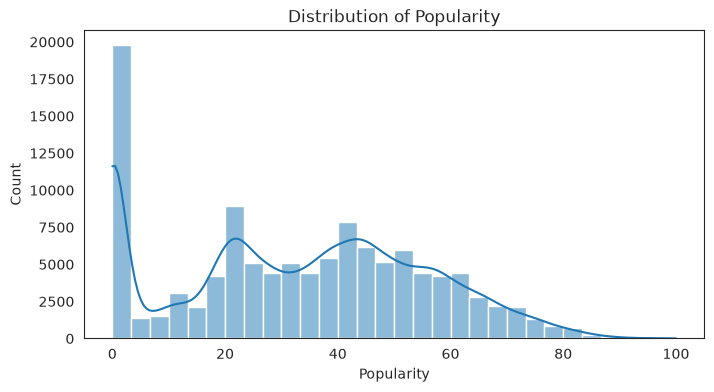

,Popularity,Count
0,0,16019
1,1,2140
2,2,1036
3,3,585
4,4,389
...,...,...
96,96,7
97,97,8
98,98,7
99,99,1


In [37]:
plt.figure(figsize=(8, 4))
sns.histplot(df['popularity'], bins=30, kde=True)
plt.title("Distribution of Popularity")
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.show()
popularity_table = df['popularity'].value_counts().sort_index().reset_index()
popularity_table.columns = ['Popularity', 'Count']
popularity_table

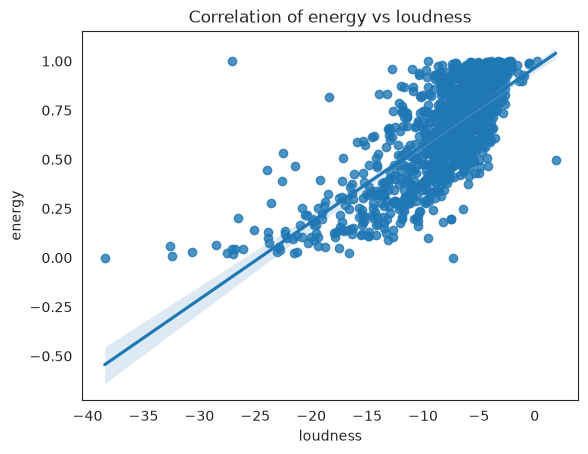

In [38]:
sample = df.sample(int(0.01 * len(df)))
sns.regplot(data=sample, y="energy", x="loudness")
plt.title("Correlation of energy vs loudness")
plt.show()

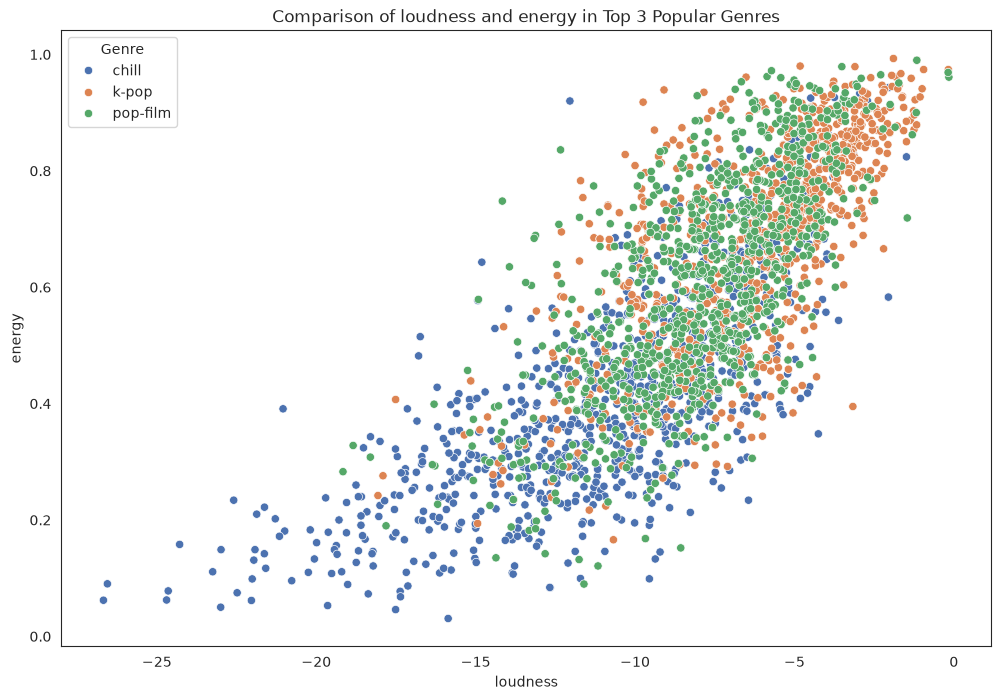

In [39]:
avg_popularity_by_genre = df.groupby('track_genre')['popularity'].mean().reset_index()
top3_popular_genres = avg_popularity_by_genre.nlargest(3, 'popularity')
top3_genre_data = df[df['track_genre'].isin(top3_popular_genres['track_genre'])]
plt.figure(figsize=(12, 8))
sns.scatterplot(x='loudness', y='energy', hue='track_genre', data=top3_genre_data, palette='deep')
plt.title('Comparison of loudness and energy in Top 3 Popular Genres')
plt.xlabel('loudness')
plt.ylabel('energy')
plt.legend(title='Genre')
plt.show()

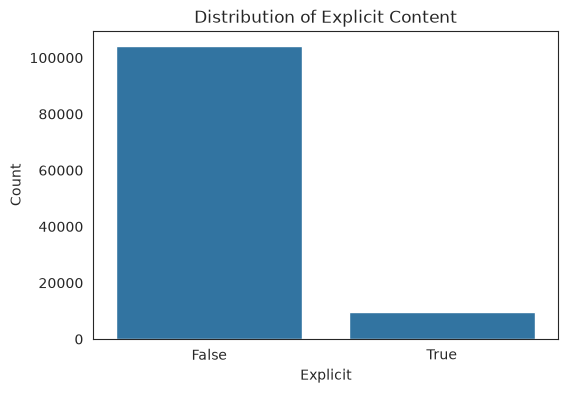

,Explicit,Count
0,False,104252
1,True,9747


In [40]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df['explicit'])
plt.title("Distribution of Explicit Content")
plt.xlabel("Explicit")
plt.ylabel("Count")
plt.show()
explicit_count_table = df['explicit'].value_counts().reset_index()
explicit_count_table.columns = ['Explicit', 'Count']
explicit_count_table

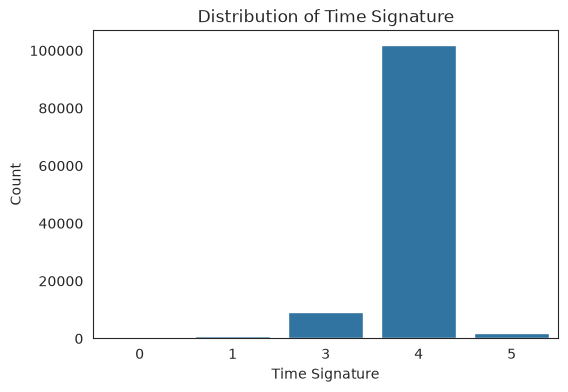

,Time Signature,Count
0,4,101842
1,3,9195
2,5,1826
3,1,973
4,0,163


In [41]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df['time_signature'])
plt.title("Distribution of Time Signature")
plt.xlabel("Time Signature")
plt.ylabel("Count")
plt.show()
time_signature_count_table = df['time_signature'].value_counts().reset_index()
time_signature_count_table.columns = ['Time Signature', 'Count']
time_signature_count_table

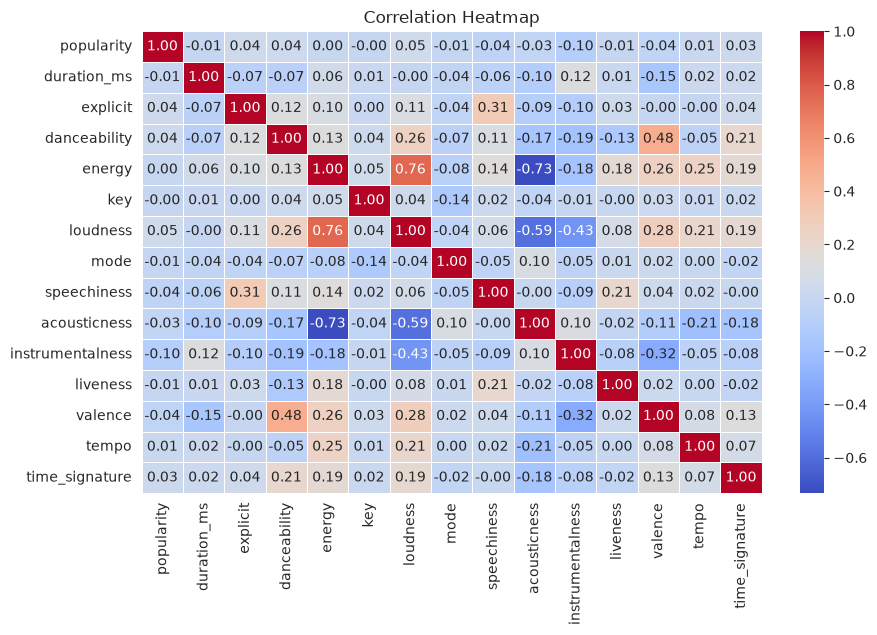

In [42]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

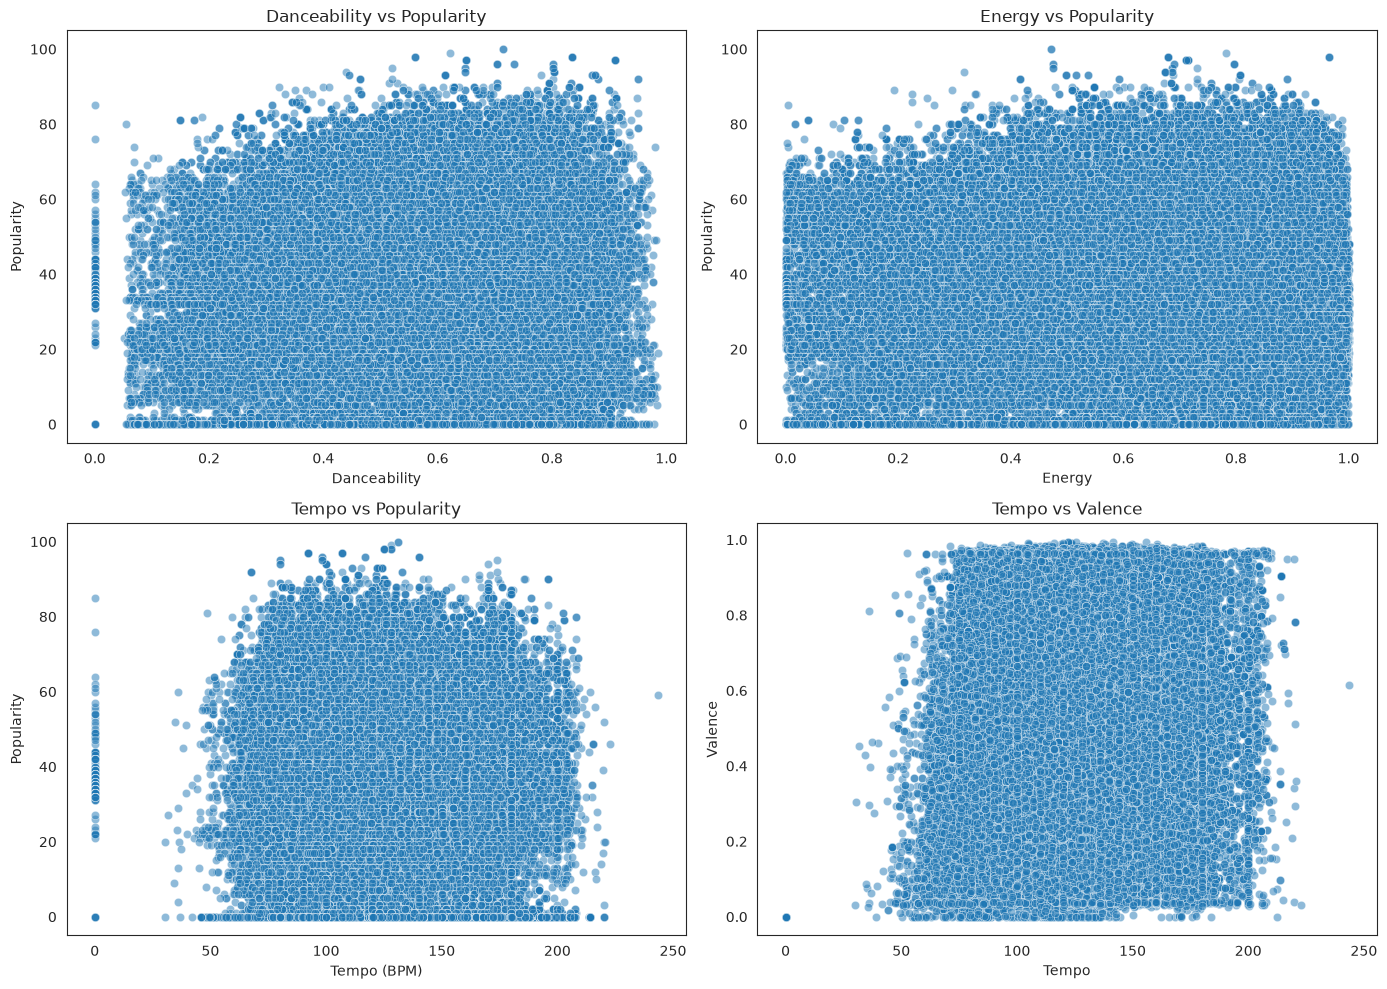

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # Create 2x2 grid for 4 plots

# Danceability vs Popularity
sns.scatterplot(x=df["danceability"], y=df["popularity"], alpha=0.5, ax=axes[0, 0])
axes[0, 0].set_title("Danceability vs Popularity")
axes[0, 0].set_xlabel("Danceability")
axes[0, 0].set_ylabel("Popularity")

# Energy vs Popularity
sns.scatterplot(x=df["energy"], y=df["popularity"], alpha=0.5, ax=axes[0, 1])
axes[0, 1].set_title("Energy vs Popularity")
axes[0, 1].set_xlabel("Energy")
axes[0, 1].set_ylabel("Popularity")

# Tempo vs Popularity
sns.scatterplot(x=df["tempo"], y=df["popularity"], alpha=0.5, ax=axes[1, 0])
axes[1, 0].set_title("Tempo vs Popularity")
axes[1, 0].set_xlabel("Tempo (BPM)")
axes[1, 0].set_ylabel("Popularity")

# Tempo vs Valence
sns.scatterplot(x=df["tempo"], y=df["valence"], alpha=0.5, ax=axes[1, 1])
axes[1, 1].set_title("Tempo vs Valence")
axes[1, 1].set_xlabel("Tempo")
axes[1, 1].set_ylabel("Valence")

plt.tight_layout()
plt.show()


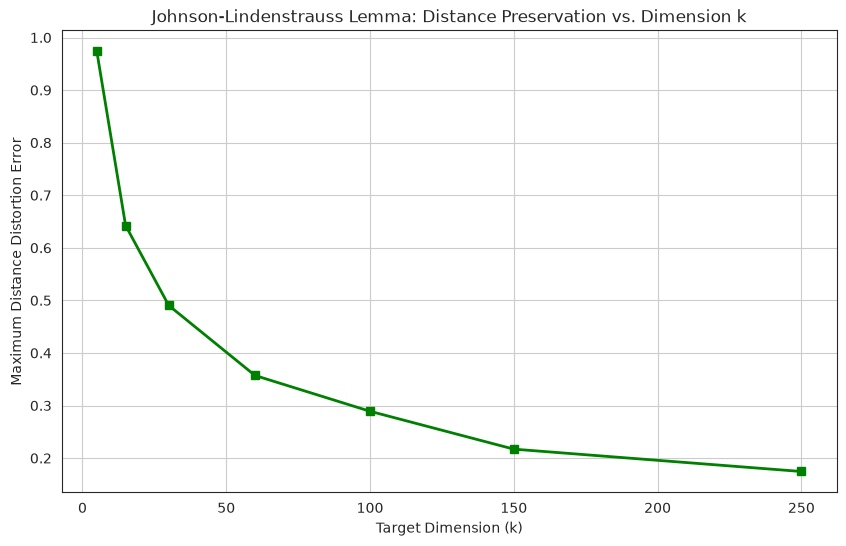

In [50]:
# Part B: Random Projection Experiment (JL Lemma)
from sklearn.metrics import pairwise_distances

# 1. Take a fixed sample of n=100 songs from the high-dimensional distribution d=300
n_jl = 100
X_high = np.random.multivariate_normal(mean, Sigma_high, size=n_jl)

# 2. Compute the original pairwise distances between all songs in the high dimension
original_distances = pairwise_distances(X_high)

# Ignore the diagonal (distance of a song to itself is 0) and keep only distances between different songs
diag_mask = ~np.eye(n_jl, dtype=bool)
orig_dist_flat = original_distances[diag_mask]

# 3. Evaluate different target dimensions (k) and observe how the error changes
k_dimensions = [5, 15, 30, 60, 100, 150, 250]
max_distortion_errors = []

for k in k_dimensions:
    # Create a Gaussian random projection matrix (normalized by sqrt(k))
    # The matrix size is (k x d)
    R = np.random.randn(k, d) / np.sqrt(k)
    
    # Project the songs to the lower dimension k (multiply the matrix by the data)
    X_low = np.dot(X_high, R.T)
    
    # Compute the new pairwise distances in the lower dimension
    low_distances = pairwise_distances(X_low)
    low_dist_flat = low_distances[diag_mask]
    
    # Compute the distance distortion ratio: new distance divided by original distance
    distortion_ratio = low_dist_flat / orig_dist_flat
    
    # Maximum error (how far the ratio deviates from 1, which represents perfect preservation)
    max_error = np.max(np.abs(distortion_ratio - 1))
    max_distortion_errors.append(max_error)

# 4. Plotting the second graph for the report
plt.figure(figsize=(10, 6))
plt.plot(k_dimensions, max_distortion_errors, marker='s', color='g', linewidth=2)
plt.xlabel('Target Dimension (k)')
plt.ylabel('Maximum Distance Distortion Error')
plt.title('Johnson-Lindenstrauss Lemma: Distance Preservation vs. Dimension k')
plt.grid(True)
plt.show()

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Define the target genres we want to evaluate
target_genres = ['rock', 'pop', 'jazz', 'country', 'acoustic']

# Filter the original dataset to include only these genres
df_filtered = df[df['track_genre'].isin(target_genres)].dropna()

# 2. Define features (X) and labels (y)
X = df_filtered[features] # Musical metrics (danceability, energy, etc.)
y = df_filtered['track_genre'] # True genre labels

# 3. Split into training and testing sets - 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Initialize and train the Random Forest model
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)

# 5. Predict on the test set (where the model cannot see the true labels)
y_pred = classifier.predict(X_test)

# 6. Print the classification performance report (Precision, Recall, F1-score)
print("--- Model Classification Performance Report ---")
print(classification_report(y_test, y_pred))

# 7. Evaluate feature importance to see which metrics contributed most to the model
importances = classifier.feature_importances_
print("--- Feature Importances ---")
for feat, imp in zip(features, importances):
    print(f"Importance of {feat}: {imp:.3f}")

--- Model Classification Performance Report ---
              precision    recall  f1-score   support

    acoustic       0.73      0.90      0.81       200
     country       0.75      0.61      0.68       200
        jazz       0.86      0.79      0.83       200
         pop       0.77      0.88      0.82       200
        rock       0.78      0.71      0.75       200

    accuracy                           0.78      1000
   macro avg       0.78      0.78      0.78      1000
weighted avg       0.78      0.78      0.78      1000

--- Feature Importances ---
Importance of danceability: 0.083
Importance of energy: 0.103
Importance of loudness: 0.098
Importance of speechiness: 0.088
Importance of acousticness: 0.125
Importance of instrumentalness: 0.053
Importance of liveness: 0.075
Importance of valence: 0.081
Importance of tempo: 0.069
Importance of popularity: 0.225


In [52]:
# 1. Define the target low dimension for the projection
k_target = 30

# 2. Create a Gaussian random projection matrix (k_target x d)
# We use d = 10 (the original number of features in the filtered dataset)
d_features = X.shape[1]
R_classifier = np.random.randn(k_target, d_features) / np.sqrt(k_target)

# 3. Project the data into the lower dimension
X_train_low = np.dot(X_train, R_classifier.T)
X_test_low = np.dot(X_test, R_classifier.T)

# 4. Train a new model on the low-dimensional data
classifier_low = RandomForestClassifier(n_estimators=100, random_state=42)
classifier_low.fit(X_train_low, y_train)

# 5. Predict and evaluate performance on the low-dimensional data
y_pred_low = classifier_low.predict(X_test_low)

print(f"--- Model Performance Report in Low Dimension (k = {k_target}) After JL Projection ---")
print(classification_report(y_test, y_pred_low))

--- Model Performance Report in Low Dimension (k = 30) After JL Projection ---
              precision    recall  f1-score   support

    acoustic       0.78      0.82      0.80       200
     country       0.66      0.58      0.62       200
        jazz       0.82      0.78      0.79       200
         pop       0.65      0.79      0.71       200
        rock       0.64      0.57      0.61       200

    accuracy                           0.71      1000
   macro avg       0.71      0.71      0.71      1000
weighted avg       0.71      0.71      0.71      1000

